# LAB ANALYSIS:

## Single Lab Analysis:

In [19]:
import pandas as pd
import numpy as np
import glob
from scipy import stats
import pingouin as pg
import os

### Processing one lab file:

In [20]:
import pandas as pd
import numpy as np

def process_single_lab_file(file_path):
    
    # Skip metadata row
    df = pd.read_csv(file_path, skiprows=[1])
    
    # Keep only rows with responses
    df = df[df['mouse.time'].notna()].copy()
    
    # Remove brackets from mouse.time
    df['mouse.time'] = (
        df['mouse.time']
        .astype(str)
        .str.replace(r'[\[\]]', '', regex=True)
    )
    
    # Convert to float
    df['RT'] = pd.to_numeric(df['mouse.time'], errors='coerce')
    
    # Convert seconds → milliseconds
    df['RT'] = df['RT'] * 1000
    
    # Accuracy
    df['Accuracy'] = df['mouse.clicked_name'].apply(
        lambda x: 1 if 'target' in str(x) else 0
    )
    
    # Remove anticipatory responses
    df = df[df['RT'] > 200]
    
    # Remove 3 SD outliers
    mean_rt = df['RT'].mean()
    sd_rt = df['RT'].std()
    df = df[df['RT'] < mean_rt + 3 * sd_rt]
    
    return df

In [59]:
    # Compute inter-click RTs per trial

def inter_click_rts(rt_list):
    if len(rt_list) == 0:
        return np.nan
    rts = [rt_list[0]]  # first click
    rts += [rt_list[i] - rt_list[i-1] for i in range(1, len(rt_list))]
    return np.mean(rts)


def process_multi_target_file(file_path):
    # Load CSV, skip metadata row if present
    df = pd.read_csv(file_path, skiprows=[1])
    
    # Keep only rows with responses
    df = df[df['mouse.time'].notna()].copy()
    
    # Remove brackets from mouse.time and convert to list of floats
    df['RT_list'] = df['mouse.time'].astype(str).str.replace(r'[\[\]]', '', regex=True).apply(
        lambda x: [float(t) for t in x.split(',')]
    )
    
    # Convert seconds → milliseconds
    df['RT_list'] = df['RT_list'].apply(lambda x: [t*1000 for t in x])
    
    df['RT_trial'] = df['RT_list'].apply(inter_click_rts)
    df['RT_first'] = df['RT_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)
    
    # Compute average first RT across trials
    avg_first_rt = df['RT_first'].mean()

    # Compute accuracy per trial
    df['Accuracy_trial'] = df['mouse.clicked_name'].apply(lambda x: [c.strip() for c in str(x).replace('[','').replace(']','').split(',')]).apply(
        lambda clicks: np.mean([1 if 'target' in c else 0 for c in clicks])
    )
    
    # Remove anticipatory trials (<200 ms first click)
    df = df[df['RT_trial'] > 200]
    
    # Remove 3 SD outliers
    mean_rt = df['RT_trial'].mean()
    sd_rt = df['RT_trial'].std()
    df = df[df['RT_trial'] < mean_rt + 3*sd_rt]
    
    return df, avg_first_rt

### Process All Single Lab Files:

In [61]:
lab_results = []
import os
single_folder_path = "C:/Users/DEDEEPYA/OneDrive/Desktop/6th sem/BRSM/BRSM_Project/data_brsm/single/lab"

for filename in os.listdir(single_folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(single_folder_path, filename)
        df = process_single_lab_file(file_path)
        lab_results.append({
            'participant': filename.split("_")[0].replace(".csv",""),
            'target_load': 'Single',
            'modality': 'Lab',
            'RT_mean(ms)': df['RT'].mean(),
            'Accuracy_mean': df['Accuracy'].mean(),
            'Initial_RT(ms)': df['RT'].mean()
        })
# Folder with multiple-target files
multi_folder_path = "C:/Users/DEDEEPYA/OneDrive/Desktop/6th sem/BRSM/BRSM_Project/data_brsm/multiple/lab"
# lab_results = []

for filename in os.listdir(multi_folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(multi_folder_path, filename)
        df, intialRT = process_multi_target_file(file_path)
        print(intialRT, filename)
        # Average across trials for this participant
        lab_results.append({
            'participant': filename.split("_")[0].replace(".csv",""),
            'target_load': 'Multiple',
            'modality': 'Lab',
            'RT_mean(ms)': df['RT_trial'].mean(),
            'Accuracy_mean': df['Accuracy_trial'].mean(),
            'Initial_RT(ms)':intialRT
        })

# Save to CSV
lab_df = pd.DataFrame(lab_results)
lab_df.to_csv("lab_results.csv", index=False)
# print("Multi-target lab results saved to multi_target_lab_results.csv")
# lab_df = pd.DataFrame(lab_results)

1330.599113333339 22_visual_search_2026-02-06_13h34.07.839.csv
1498.6478333333405 23_visual_search_2026-02-06_13h54.30.043.csv
1997.2415266666453 24_visual_search_2026-02-06_13h51.11.393.csv
1338.801493333449 25_visual_search_2026-02-06_16h02.12.148.csv
1780.876733333207 26_visual_search_2026-02-06_15h57.34.272.csv
1373.8547133333325 27_visual_search_2026-02-07_05h42.18.301.csv
1609.014653333331 28_visual_search_2026-02-07_05h49.57.981.csv
1268.6897666666787 29_visual_search_2026-02-07_05h58.57.667.csv
2103.0041999999717 30_visual_search_2026-02-07_06h26.38.028.csv
1497.8926600000098 31_visual_search_2026-02-07_06h42.42.482.csv
1556.2989399999994 32_visual_search_2026-02-08_06h11.56.198.csv
1430.43959333332 33_visual_search_2026-02-07_13h47.10.439.csv
1463.7053466666355 34_visual_search_2026-02-08_07h04.24.925.csv
1760.4853533333273 35_visual_search_2026-02-07_13h58.15.358.csv
1542.5416466666813 36_visual_search_2026-02-10_18h00.07.778.csv
2128.5374466666476 37_visual_search_2026-02-10

## Plots:

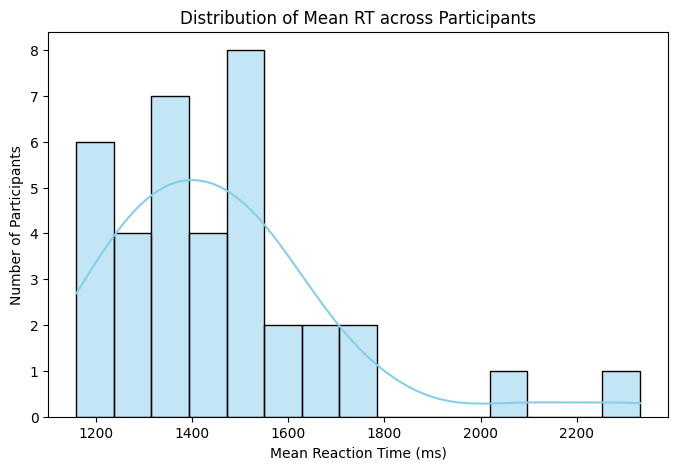

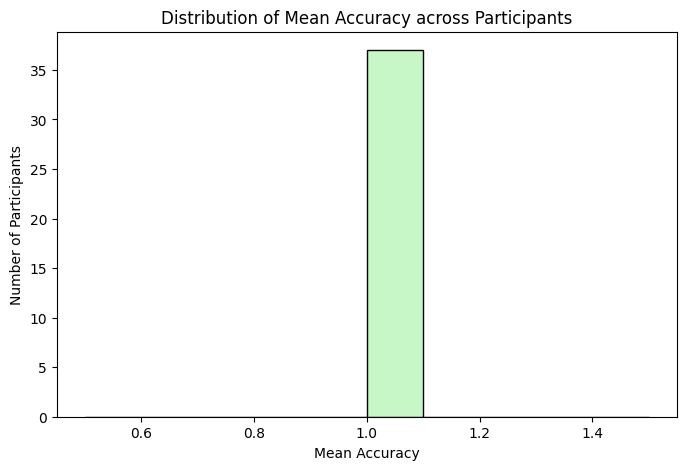

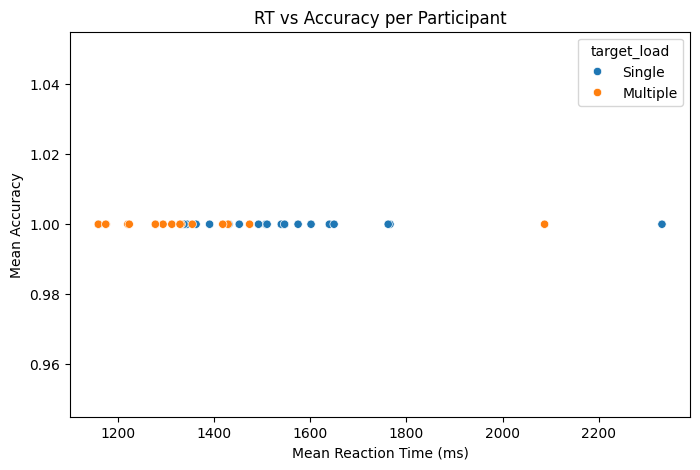

C:\Users\DEDEEPYA\AppData\Local\Temp\ipykernel_24084\3395208642.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lab_df, x='target_load', y='RT_mean', palette='pastel')


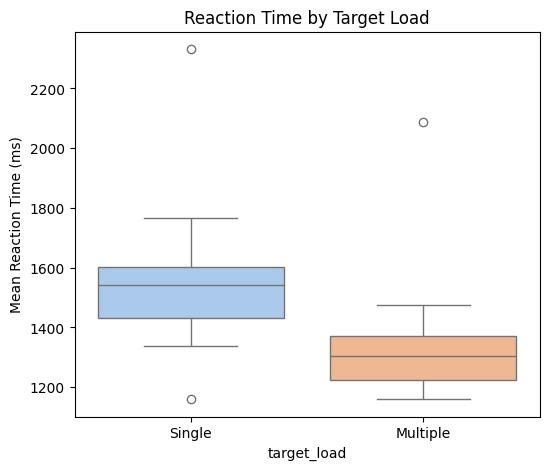

C:\Users\DEDEEPYA\AppData\Local\Temp\ipykernel_24084\3395208642.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lab_df, x='target_load', y='Accuracy_mean', palette='Set2')


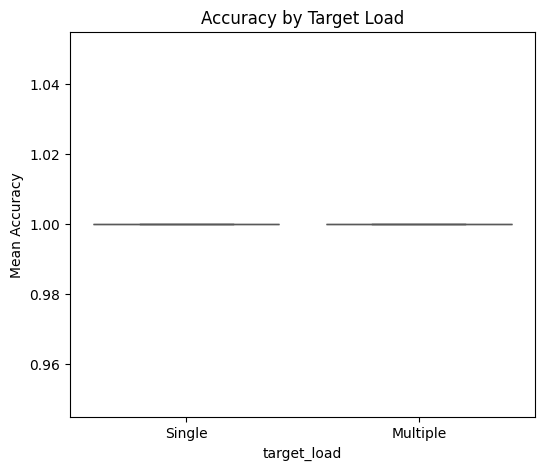

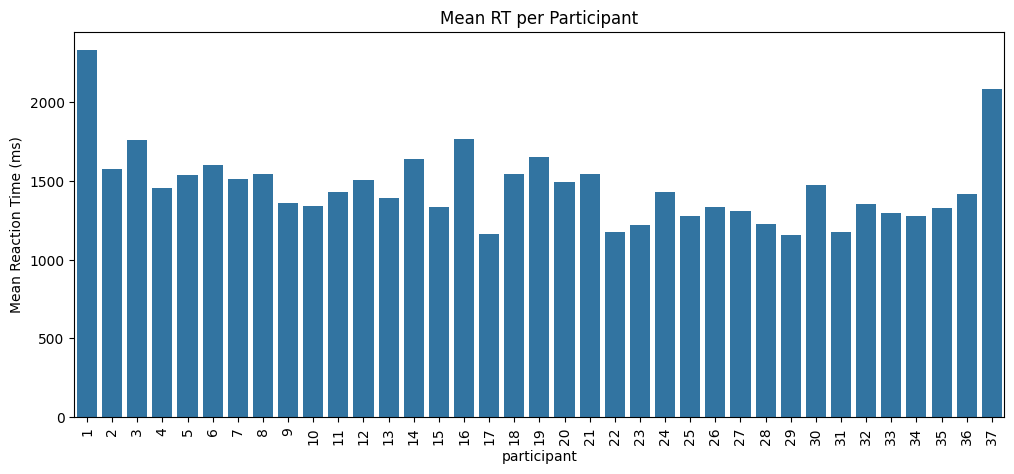

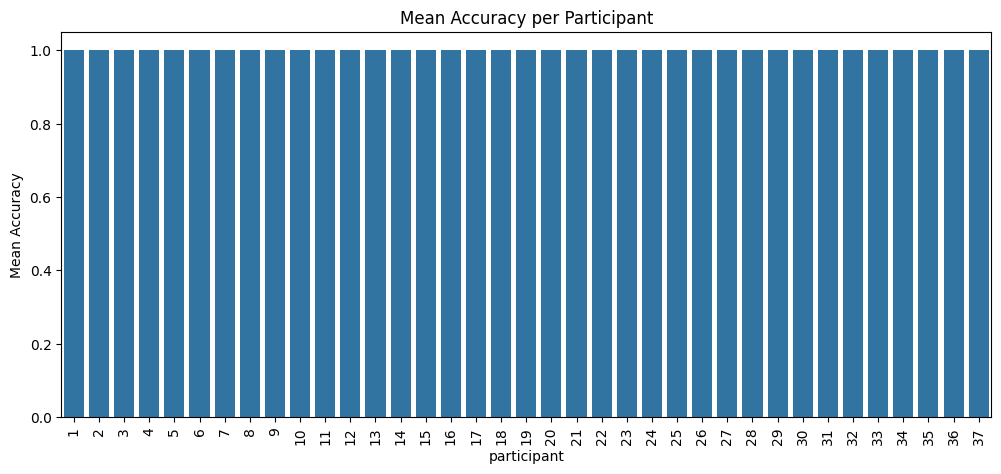

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Load summary CSV
# ----------------------------
lab_df = pd.read_csv("lab_results.csv")

# Strip spaces from column names just in case
lab_df.columns = lab_df.columns.str.strip()

# ----------------------------
# 1. Distribution of mean RT across participants
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(lab_df['RT_mean'], bins=15, kde=True, color='skyblue')
plt.xlabel('Mean Reaction Time (ms)')
plt.ylabel('Number of Participants')
plt.title('Distribution of Mean RT across Participants')
plt.show()

# ----------------------------
# 2. Distribution of mean Accuracy across participants
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(lab_df['Accuracy_mean'], bins=10, kde=True, color='lightgreen')
plt.xlabel('Mean Accuracy')
plt.ylabel('Number of Participants')
plt.title('Distribution of Mean Accuracy across Participants')
plt.show()

# ----------------------------
# 3. Scatter plot: RT vs Accuracy
# ----------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=lab_df, x='RT_mean', y='Accuracy_mean', hue='target_load')
plt.xlabel('Mean Reaction Time (ms)')
plt.ylabel('Mean Accuracy')
plt.title('RT vs Accuracy per Participant')
plt.show()

# ----------------------------
# 4. Boxplot: RT by target load
# ----------------------------
plt.figure(figsize=(6,5))
sns.boxplot(data=lab_df, x='target_load', y='RT_mean', palette='pastel')
plt.ylabel('Mean Reaction Time (ms)')
plt.title('Reaction Time by Target Load')
plt.show()

# ----------------------------
# 5. Boxplot: Accuracy by target load
# ----------------------------
plt.figure(figsize=(6,5))
sns.boxplot(data=lab_df, x='target_load', y='Accuracy_mean', palette='Set2')
plt.ylabel('Mean Accuracy')
plt.title('Accuracy by Target Load')
plt.show()

# ----------------------------
# 6. Bar plot: Mean RT per participant
# ----------------------------
plt.figure(figsize=(12,5))
sns.barplot(data=lab_df, x='participant', y='RT_mean')
plt.xticks(rotation=90)
plt.ylabel('Mean Reaction Time (ms)')
plt.title('Mean RT per Participant')
plt.show()

# ----------------------------
# 7. Bar plot: Mean Accuracy per participant
# ----------------------------
plt.figure(figsize=(12,5))
sns.barplot(data=lab_df, x='participant', y='Accuracy_mean')
plt.xticks(rotation=90)
plt.ylabel('Mean Accuracy')
plt.title('Mean Accuracy per Participant')
plt.show()

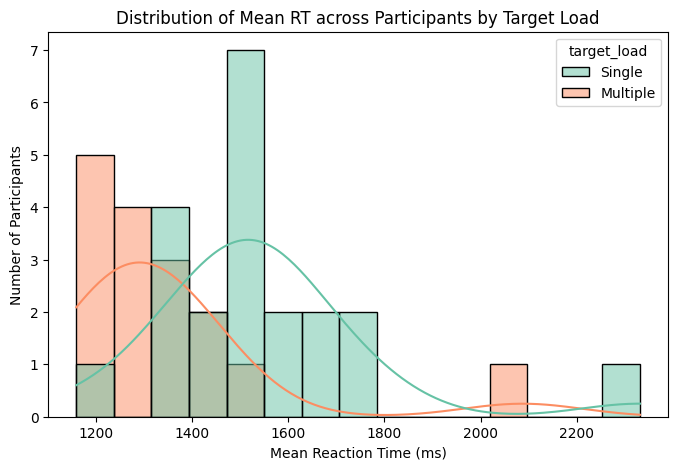

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    data=lab_df, 
    x='RT_mean', 
    bins=15, 
    hue='target_load', 
    kde=True, 
    palette='Set2', 
    alpha=0.5
)
plt.xlabel('Mean Reaction Time (ms)')
plt.ylabel('Number of Participants')
plt.title('Distribution of Mean RT across Participants by Target Load')
plt.show()

<Axes: xlabel='RT_mean', ylabel='Count'>

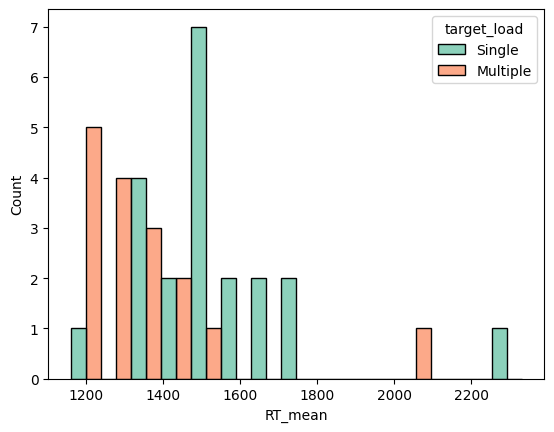

In [50]:
sns.histplot(data=lab_df, x='RT_mean', bins=15, hue='target_load', multiple='dodge', palette='Set2')

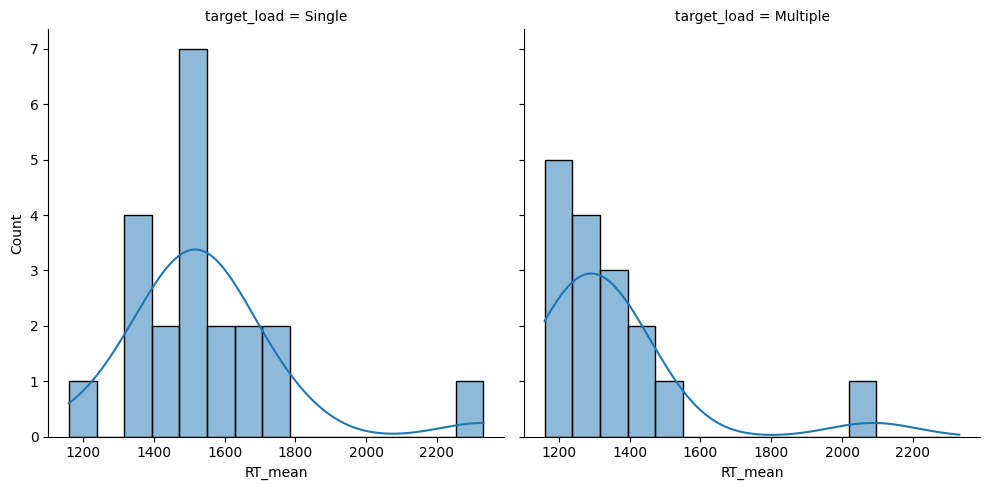

In [51]:
sns.displot(data=lab_df, x='RT_mean', col='target_load', bins=15, kde=True, height=5, aspect=1)